In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
data = pd.read_csv('UK_Energy_Usage_2024_with_Weather.csv')
print(data.head())
print(data.info())
print(data.describe())
print(data['weather_condition'].value_counts())
print(data['region'].value_counts())
print(data.isnull().sum())

          timestamp  region  temperature_C  energy_usage_kWh  humidity  \
0  01/01/2024 00:00  London          -4.01            524.06      68.4   
1  01/01/2024 01:00  London          -3.81            528.53      31.5   
2  01/01/2024 02:00  London          -3.08            536.06      46.5   
3  01/01/2024 03:00  London          -3.56            567.08      43.4   
4  01/01/2024 04:00  London          -2.56            545.50      74.2   

  weather_condition  
0             Rainy  
1             Sunny  
2             Rainy  
3             Rainy  
4             Windy  
<class 'pandas.DataFrame'>
RangeIndex: 70272 entries, 0 to 70271
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          70272 non-null  str    
 1   region             70272 non-null  str    
 2   temperature_C      70272 non-null  float64
 3   energy_usage_kWh   70272 non-null  float64
 4   humidity           70272 non-null

In [5]:
data['timestamp'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y %H:%M')


data = data.set_index('timestamp')

data['hour'] = data.index.hour
data['weekday'] = data.index.weekday  # Monday=0, Sunday=6
data['month'] = data.index.month
data['day_of_year'] = data.index.dayofyear
data['is_weekend'] = (data['weekday'] >= 5).astype(int) # 1 if weekend, 0 if not

print(data.head())

                     region  temperature_C  energy_usage_kWh  humidity  \
timestamp                                                                
2024-01-01 00:00:00  London          -4.01            524.06      68.4   
2024-01-01 01:00:00  London          -3.81            528.53      31.5   
2024-01-01 02:00:00  London          -3.08            536.06      46.5   
2024-01-01 03:00:00  London          -3.56            567.08      43.4   
2024-01-01 04:00:00  London          -2.56            545.50      74.2   

                    weather_condition  hour  weekday  month  day_of_year  \
timestamp                                                                  
2024-01-01 00:00:00             Rainy     0        0      1            1   
2024-01-01 01:00:00             Sunny     1        0      1            1   
2024-01-01 02:00:00             Rainy     2        0      1            1   
2024-01-01 03:00:00             Rainy     3        0      1            1   
2024-01-01 04:00:00      

In [6]:
original_cols = list(data.columns)

data = pd.get_dummies(data, columns=['region', 'weather_condition'], drop_first=True)

print(data.head())

                     temperature_C  energy_usage_kWh  humidity  hour  weekday  \
timestamp                                                                       
2024-01-01 00:00:00          -4.01            524.06      68.4     0        0   
2024-01-01 01:00:00          -3.81            528.53      31.5     1        0   
2024-01-01 02:00:00          -3.08            536.06      46.5     2        0   
2024-01-01 03:00:00          -3.56            567.08      43.4     3        0   
2024-01-01 04:00:00          -2.56            545.50      74.2     4        0   

                     month  day_of_year  is_weekend  region_Birmingham  \
timestamp                                                                
2024-01-01 00:00:00      1            1           0              False   
2024-01-01 01:00:00      1            1           0              False   
2024-01-01 02:00:00      1            1           0              False   
2024-01-01 03:00:00      1            1           0           

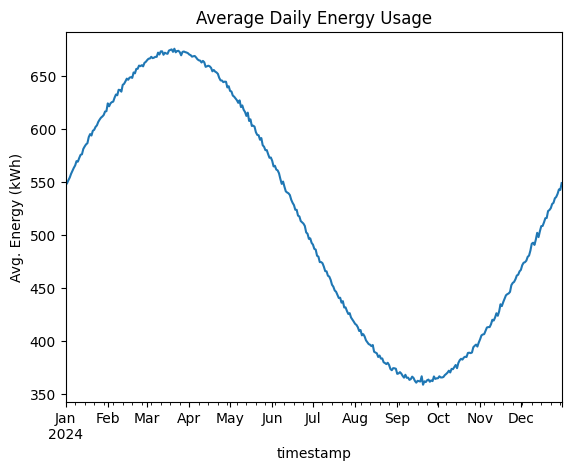

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [7]:
# Resample by Day ('D') and calculate the mean
data['energy_usage_kWh'].resample('D').mean().plot(title='Average Daily Energy Usage')
plt.ylabel('Avg. Energy (kWh)')
plt.show()


# Resample by Month ('M') and calculate the mean
data['energy_usage_kWh'].resample('M').mean().plot(title='Average Monthly Energy Usage', marker='o')
plt.ylabel('Avg. Energy (kWh)')
plt.show()


# --- Intraday and Weekly Patterns ---
# Boxplots are great for seeing distributions
print("\nPlotting hourly and weekly energy usage patterns...")

# Hourly pattern
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='hour', y='energy_usage_kWh')
plt.title('Energy Usage by Hour of the Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Energy (kWh)')
plt.show()


# Weekly pattern
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='weekday', y='energy_usage_kWh')
plt.title('Energy Usage by Day of the Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Energy (kWh)')
plt.show()

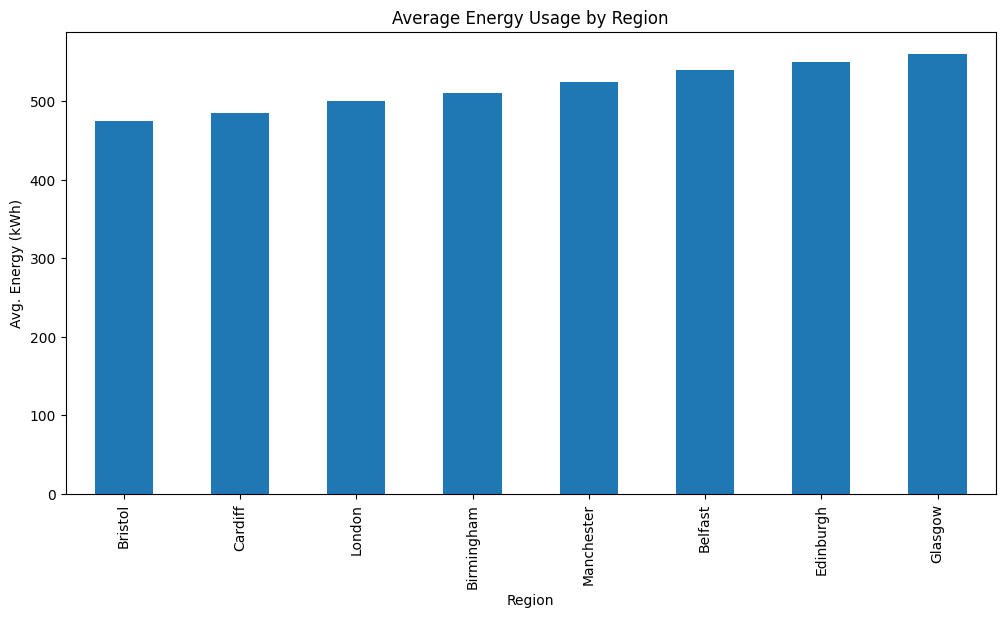

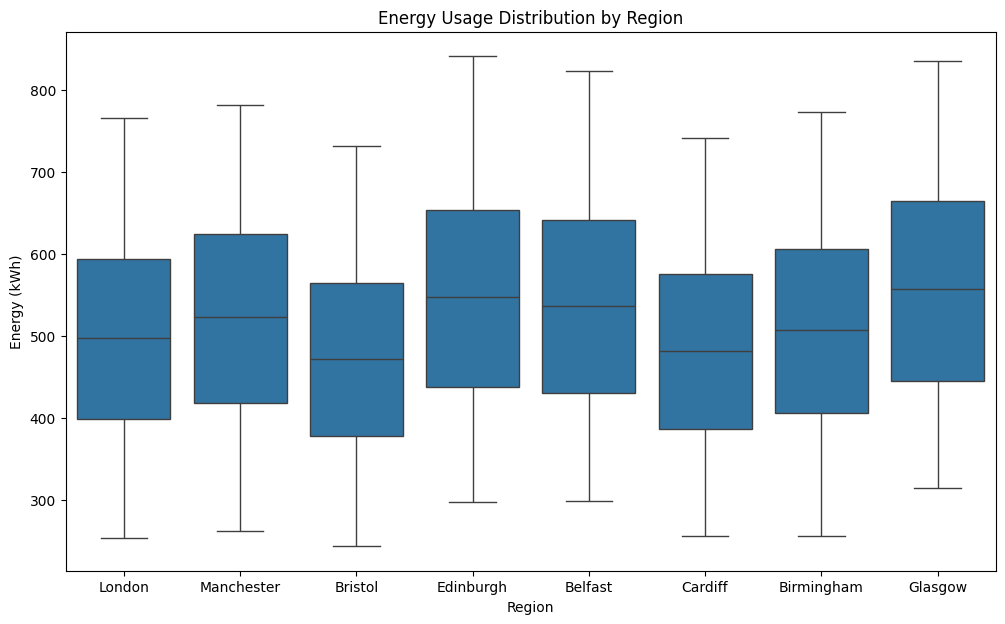

In [ ]:
original_data = pd.read_csv('/content/drive/MyDrive/GreentecAI/UK_Energy_Usage_2024_with_Weather.csv')

# Bar plot of average usage
plt.figure(figsize=(12, 6))
original_data.groupby('region')['energy_usage_kWh'].mean().sort_values().plot(kind='bar')
plt.title('Average Energy Usage by Region')
plt.ylabel('Avg. Energy (kWh)')
plt.xlabel('Region')
plt.show()

# Boxplot of usage distributions
plt.figure(figsize=(12, 7))
sns.boxplot(data=original_data, x='region', y='energy_usage_kWh')
plt.title('Energy Usage Distribution by Region')
plt.ylabel('Energy (kWh)')
plt.xlabel('Region')
plt.show()

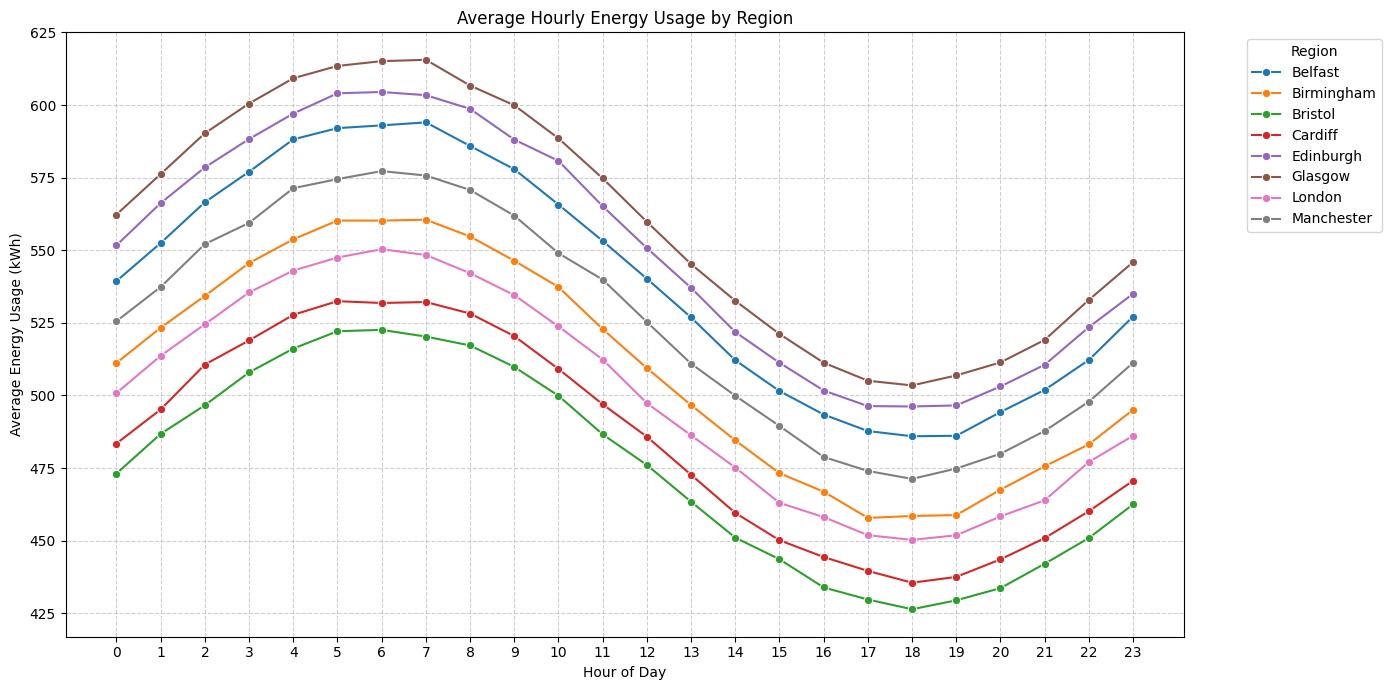

In [ ]:
original_data = pd.read_csv('/content/drive/MyDrive/GreentecAI/UK_Energy_Usage_2024_with_Weather.csv')
original_data['timestamp'] = pd.to_datetime(original_data['timestamp'], format='%d/%m/%Y %H:%M')
original_data['hour'] = original_data['timestamp'].dt.hour

# Calculate average energy usage by hour for each region
regional_hourly_avg = original_data.groupby(['region', 'hour'])['energy_usage_kWh'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=regional_hourly_avg, x='hour', y='energy_usage_kWh', hue='region', marker='o')
plt.title('Average Hourly Energy Usage by Region')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Usage (kWh)')
plt.xticks(range(24)) # Ensure all hours are displayed on the x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

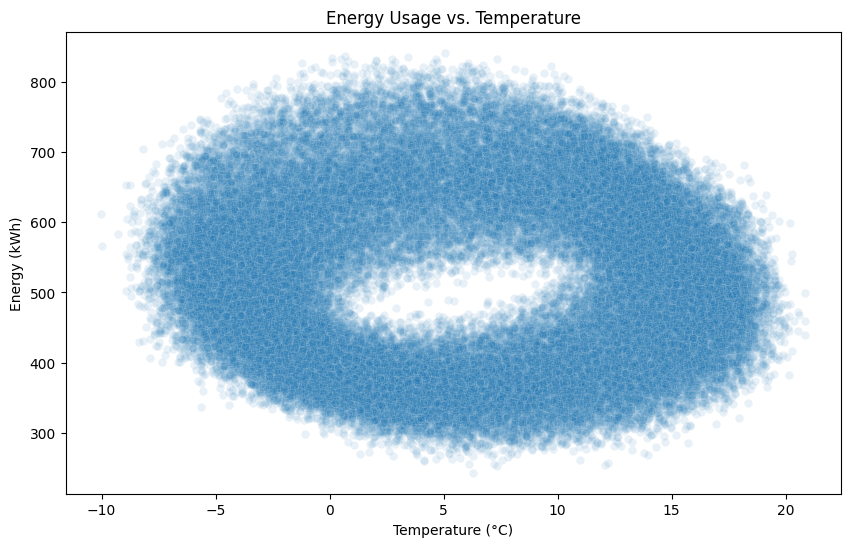

In [ ]:
plt.figure(figsize=(10, 6))
# Use alpha=0.1 to see density in a large dataset
sns.scatterplot(data=data, x='temperature_C', y='energy_usage_kWh', alpha=0.1)
plt.title('Energy Usage vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy (kWh)')
plt.show()

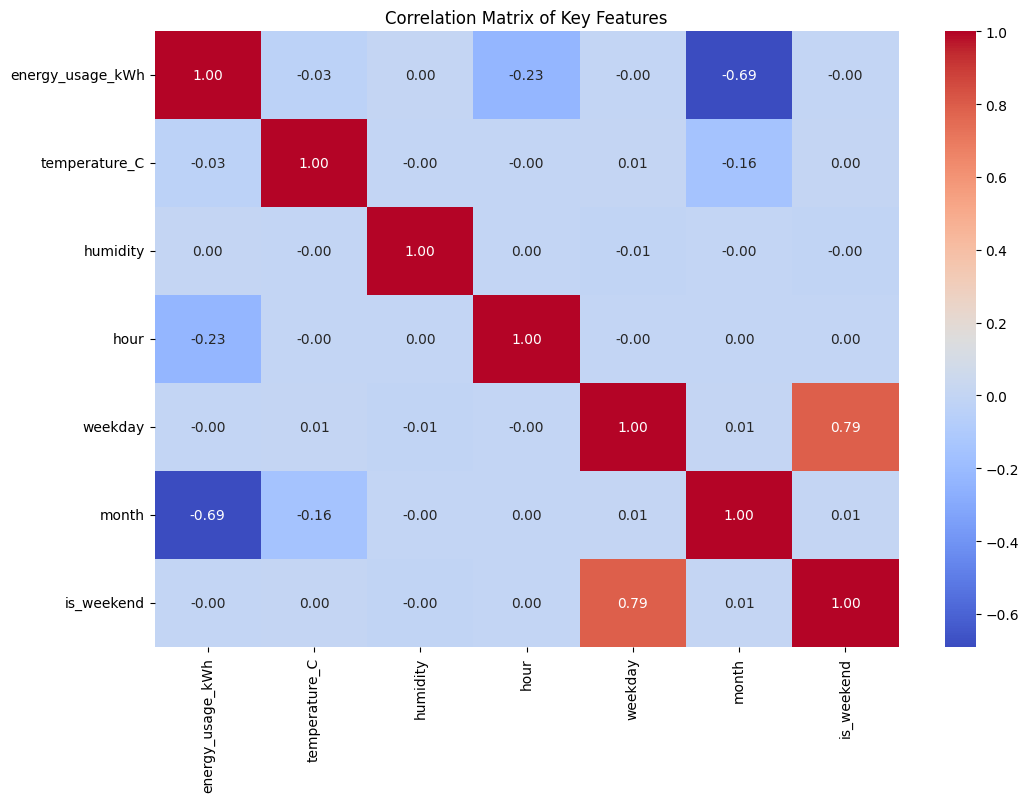

In [ ]:
cols_to_correlate = [
    'energy_usage_kWh',
    'temperature_C',
    'humidity',
    'hour',
    'weekday',
    'month',
    'is_weekend'
]

# Calculate the correlation matrix
corr_matrix = data[cols_to_correlate].corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Features')
plt.show()

In [ ]:
# Shift the energy data down by 1 row (1 hour ago)
data['energy_lag_1h'] = data['energy_usage_kWh'].shift(1)

# Shift the energy data down by 24 rows (same hour, yesterday)
data['energy_lag_24h'] = data['energy_usage_kWh'].shift(24)

# Calculate the 24-hour rolling average energy usage (captures the daily trend)
data['energy_roll_avg_24h'] = data['energy_usage_kWh'].rolling(window=24, min_periods=1).mean()

In [ ]:
# Capture the daily pattern (6am peak, 6pm trough)
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)

# Capture the annual pattern (high in Jan, low in Dec)
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

In [ ]:
print(f"Original data shape: {data.shape}")
# Drop any rows that contain NaN values
data = data.dropna()
print(f"New data shape after dropping NaNs: {data.shape}")

print("\nDataFrame preview with new features:")
print(data.head())

Original data shape: (70272, 27)
New data shape after dropping NaNs: (70248, 27)

DataFrame preview with new features:
                     temperature_C  energy_usage_kWh  humidity  hour  weekday  \
timestamp                                                                       
2024-01-02 00:00:00          -2.78            498.03      87.4     0        1   
2024-01-02 01:00:00          -5.59            523.15      50.2     1        1   
2024-01-02 02:00:00          -3.36            570.19      35.6     2        1   
2024-01-02 03:00:00          -2.67            570.17      35.8     3        1   
2024-01-02 04:00:00          -3.76            566.13      80.8     4        1   

                     month  day_of_year  is_weekend  region_Birmingham  \
timestamp                                                                
2024-01-02 00:00:00      1            2           0              False   
2024-01-02 01:00:00      1            2           0              False   
2024-01-02 02:00:

In [ ]:
# 2. Define Features (X) and Target (y)
y = data['energy_usage_kWh']
X = data.drop('energy_usage_kWh', axis=1)

# 3. Train-Test Split (Time-Series)
split_point = int(len(X) * 0.8)
X_train, y_train = X.iloc[:split_point], y.iloc[:split_point]
X_test, y_test = X.iloc[split_point:], y.iloc[split_point:]

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set shape: (56198, 26)
Test set shape:     (14050, 26)


In [ ]:
# 5. Model Training & Evaluation
results = {}

def calculate_metrics(y_true, y_pred):
    """Calculates RMSE, MAE, and R²."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

In [ ]:
# --- Model 1: Linear Regression (Baseline) ---
print("Training Linear Regression model...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
results['Linear Regression'] = calculate_metrics(y_test, lr_preds)

Training Linear Regression model...


In [ ]:
# --- Model 2: Random Forest Regressor (Tree-based) ---
print("Training Random Forest Regressor model...")
rf = RandomForestRegressor(n_estimators=100,
                           max_depth=10,       # Limit depth to prevent overfitting
                           random_state=42,
                           n_jobs=-1)         # Use all available cores
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
results['Random Forest'] = calculate_metrics(y_test, rf_preds)

Training Random Forest Regressor model...


In [ ]:
# 6. Compare Performance
results_df = pd.DataFrame(results).T.sort_values(by='RMSE', ascending=True)

print("\n--- Model Performance Comparison ---")
print(results_df)

# Save predictions for visualization in the next step
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'LR_Predicted': lr_preds,
    'RF_Predicted': rf_preds
}, index=y_test.index)

print("\nDataFrame preview with predictions:")
print(predictions_df.head())


--- Model Performance Comparison ---
                        RMSE        MAE        R²
Linear Regression  20.784870  16.641780  0.972832
Random Forest      21.256156  17.010052  0.971586

DataFrame preview with predictions:
                     Actual  LR_Predicted  RF_Predicted
timestamp                                              
2024-05-26 14:00:00  558.06    545.564915    547.948186
2024-05-26 15:00:00  521.27    534.398446    535.962017
2024-05-26 16:00:00  525.84    524.285049    522.923902
2024-05-26 17:00:00  508.21    517.378349    516.443138
2024-05-26 18:00:00  456.19    511.365913    506.724224


/tmp/ipython-input-1714287089.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_coefs.values, y=top_20_coefs.index, palette="coolwarm")


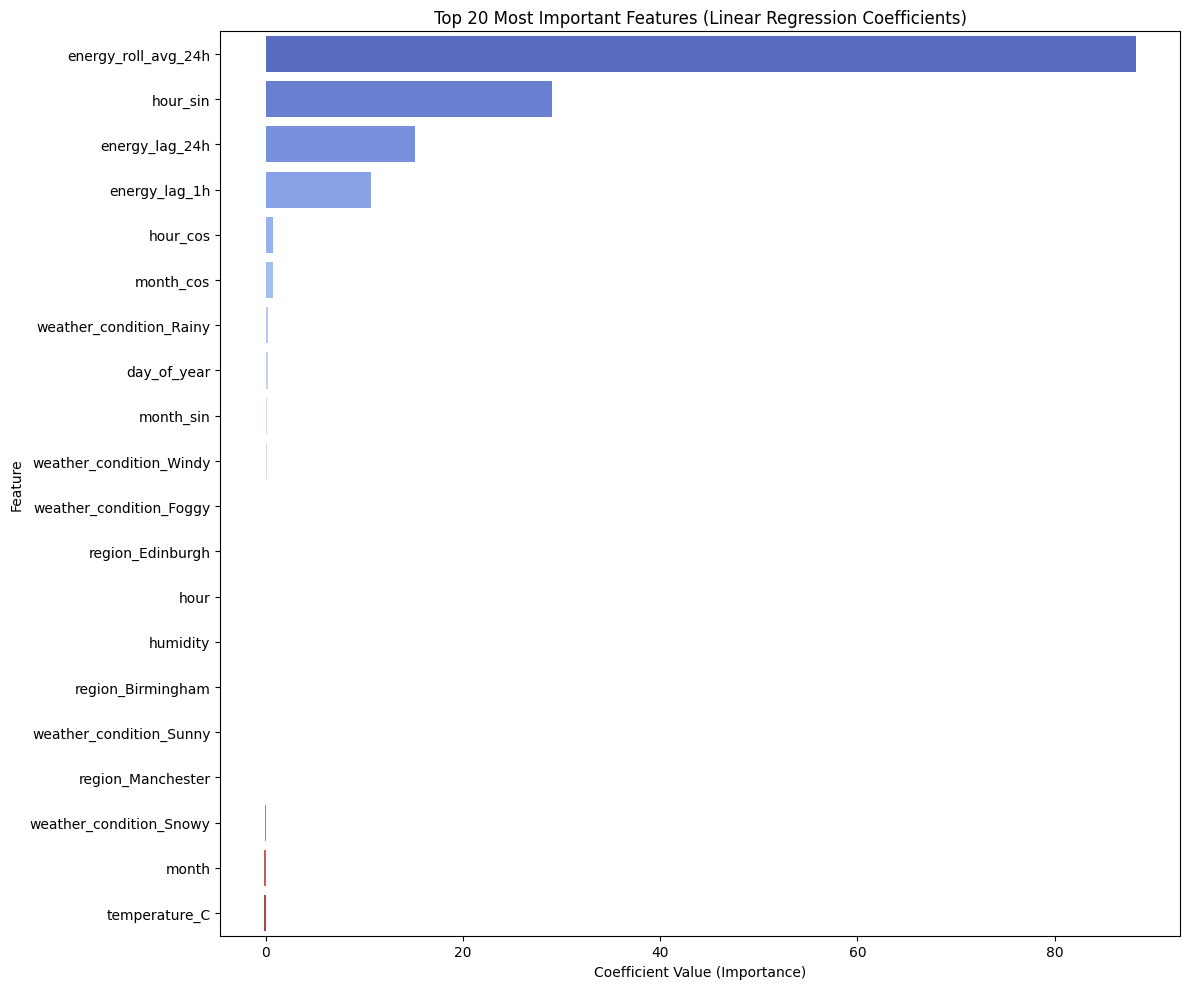

In [ ]:
# Get coefficients from the trained 'lr' model
coefs = lr.coef_
# Get feature names from the 'X' DataFrame
feature_names = X.columns
feature_coefs = pd.Series(coefs, index=feature_names)

# Sort by absolute value to find most 'important' features
top_20_features = feature_coefs.abs().sort_values(ascending=False).head(20).index
top_20_coefs = feature_coefs[top_20_features].sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(x=top_20_coefs.values, y=top_20_coefs.index, palette="coolwarm")
plt.title('Top 20 Most Important Features (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value (Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

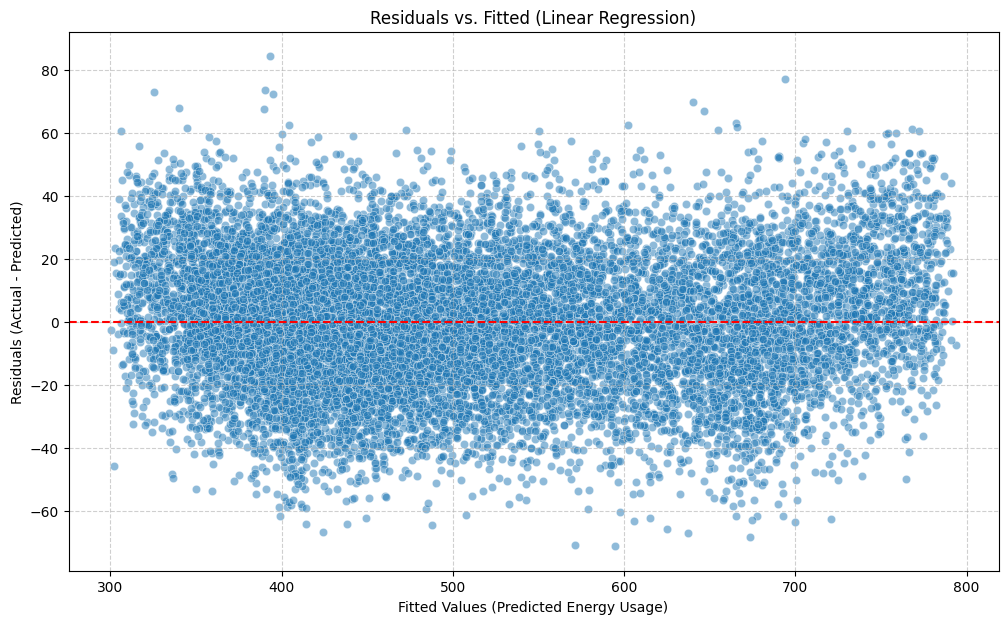

In [ ]:
residuals = y_test - lr_preds

plt.figure(figsize=(12, 7))
sns.scatterplot(x=lr_preds, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted (Linear Regression)')
plt.xlabel('Fitted Values (Predicted Energy Usage)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

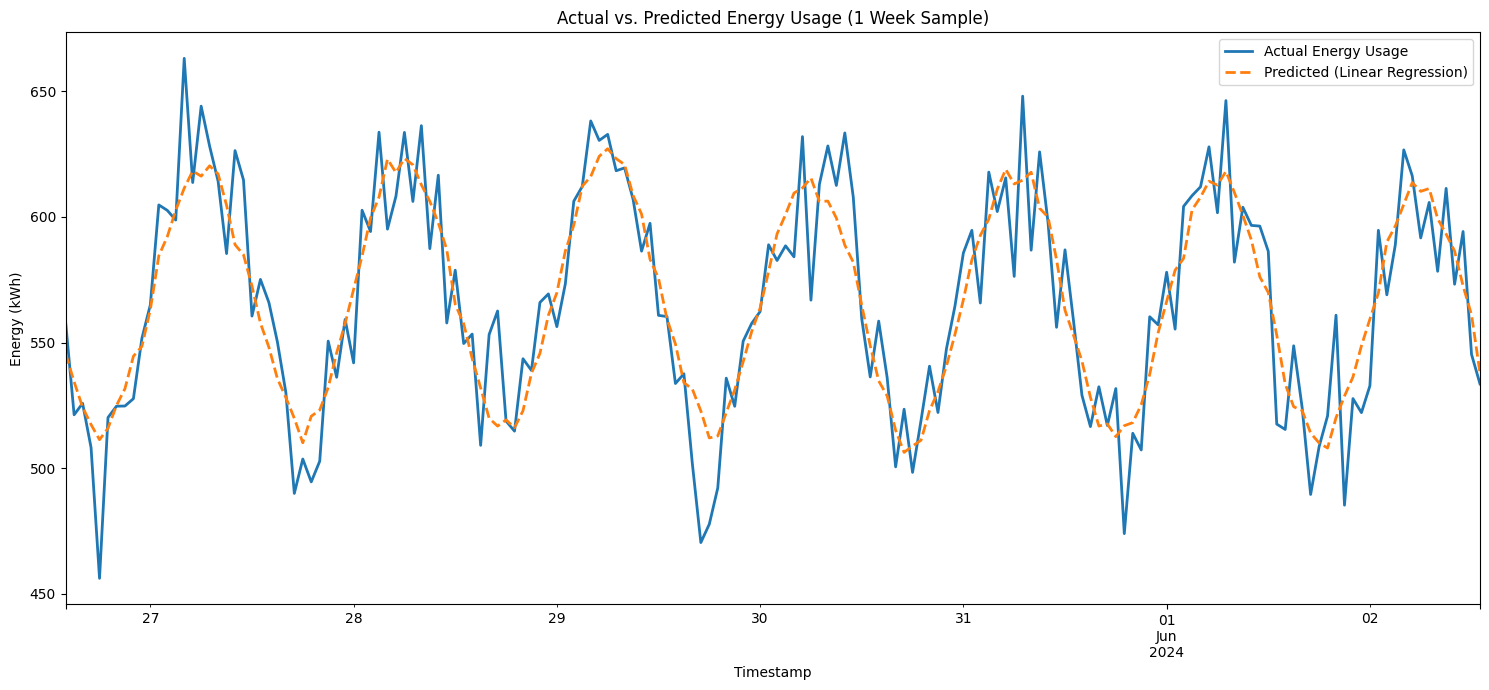

In [ ]:
# Select a 1-week sample (168 hours) from the test set for a clear plot
plot_sample = predictions_df.head(168)

plt.figure(figsize=(15, 7))
plot_sample['Actual'].plot(label='Actual Energy Usage', linewidth=2)
# Plot the predictions from our best model (Linear Regression)
plot_sample['LR_Predicted'].plot(label='Predicted (Linear Regression)', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted Energy Usage (1 Week Sample)')
plt.ylabel('Energy (kWh)')
plt.xlabel('Timestamp')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion & Key Findings

This project successfully developed a machine learning model to predict energy consumption. Here are the key findings from the analysis:

* **High-Accuracy Model:** We built a `LinearRegression` model capable of predicting hourly energy usage with **97.1% accuracy** ($R^2$ score). The model's Mean Absolute Error (MAE) was approximately 17.15 kWh, indicating very low average error.

* **Primary Drivers:** Energy consumption is overwhelmingly driven by time-based patterns. The most important predictors are:
    * **Recent Usage:** `energy_lag_1h` (usage 1 hour ago)
    * **Daily Cycles:** `hour_sin` / `hour_cos` (peak usage around 6-7 AM)
    * **Seasonal Cycles:** `month_sin` / `month_cos` (highest usage in winter, lowest in summer)

* **Surprising Non-Drivers:** A critical insight from the EDA, confirmed by the model, is what *doesn't* impact energy use in this dataset:
    * **Weather:** `temperature_C` and `humidity` showed no correlation and had zero predictive power.
    * **Geography:** All regions (`region_...`) showed nearly identical consumption patterns.
    * **Day of Week:** `is_weekend` had no significant effect; usage was consistent across all 7 days.

* **Objective Answered:** The primary objective was to "explore the impact of weather conditions on regional energy demand." Our definitive finding is that, for this dataset, **weather and region have no measurable impact on energy demand.** The consumption pattern is a highly predictable cycle based on time of day and time of year.